**Prática de Histogramas**

1) 
- Produza a imagem ‘negativa’ do arquivo ‘im_cells.png’
- Com a imagem negativa, produza a imagem original novamente. 
- Mostre lado a lado a imagem original e a negativa. Em qual deles os objetos presentes na imagem são melhor percebidos? Justifique.
- Aplique a imagem uma função logarítmica.


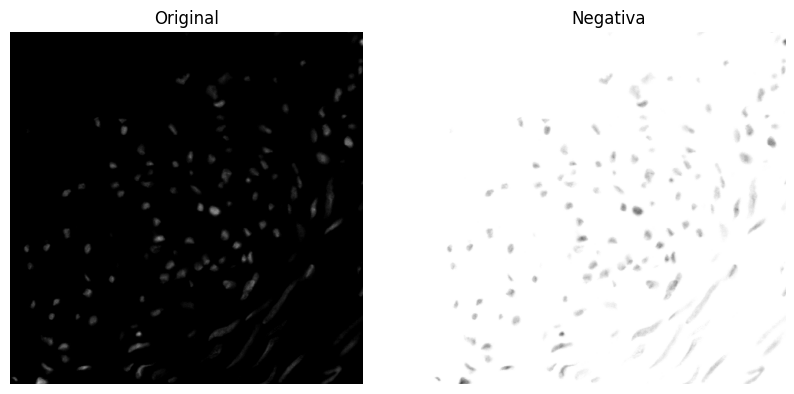

In [3]:
import cv2
import matplotlib.pyplot as plt

imagem = cv2.imread('im_cells.png')


imagem_negativa = 255 - imagem

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(imagem)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(imagem_negativa)
plt.title("Negativa")
plt.axis('off')

plt.show()

2)
- Abra a imagem 'pout.tif' e mostre seu histograma.
- Equalize a imagem anterior e mostre novamente seu histograma. Mostra a curva de transformação (consulte https://www.mathworks.com/help/images/histogram-equalization.html)
(procurar função OpenCV)



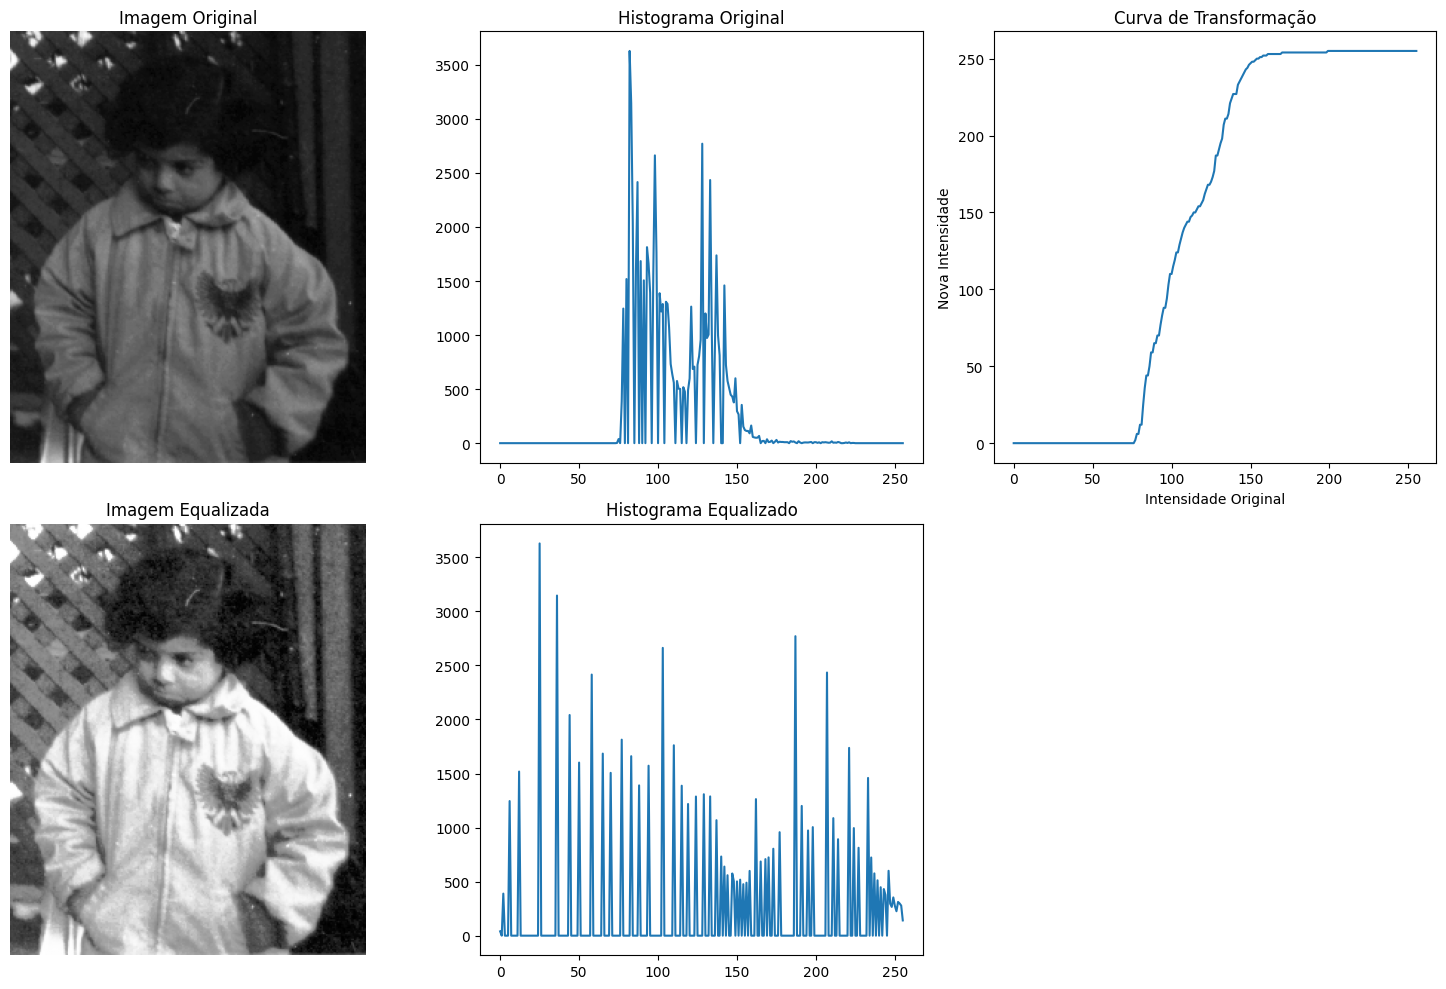

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


imagem = cv2.imread('pout.tif', cv2.IMREAD_GRAYSCALE)

imagem_eq = cv2.equalizeHist(imagem)

hist_original = cv2.calcHist([imagem], [0], None, [256], [0,256])

hist_equalizado = cv2.calcHist([imagem_eq], [0], None, [256], [0,256])

hist = hist_original.flatten()
pdf = hist / hist.sum()


cdf = pdf.cumsum()


transformacao = np.round(cdf * 255)


plt.figure(figsize=(15,10))


plt.subplot(2,3,1)
plt.imshow(imagem, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')


plt.subplot(2,3,2)
plt.plot(hist_original)
plt.title('Histograma Original')


plt.subplot(2,3,3)
plt.plot(transformacao)
plt.title('Curva de Transformação')
plt.xlabel('Intensidade Original')
plt.ylabel('Nova Intensidade')


plt.subplot(2,3,4)
plt.imshow(imagem_eq, cmap='gray')
plt.title('Imagem Equalizada')
plt.axis('off')


plt.subplot(2,3,5)
plt.plot(hist_equalizado)
plt.title('Histograma Equalizado')

plt.tight_layout()
plt.show()

3) *Implemente* o algoritmo de equalização de histograma e aplique a imagem ‘imcells.png’. Use o mínimos de laços for - tente realizar operações diretas com matrizes e vetores do numpy
- Aplique o mesmo algortimo 2x na mesma imagem e compare os resultados

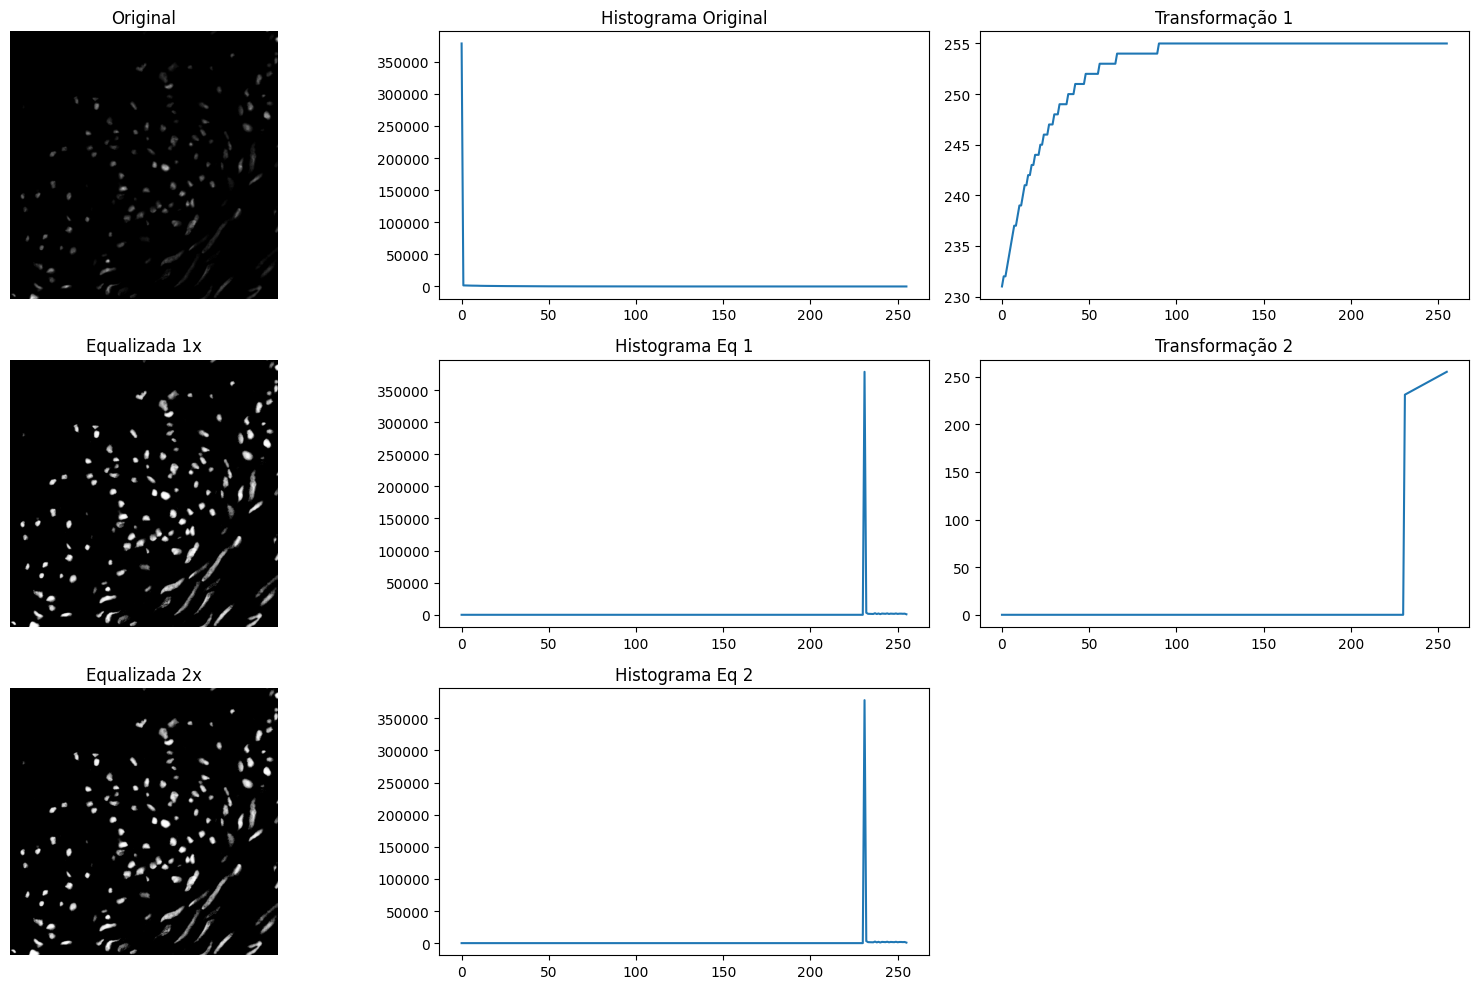

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagem = cv2.imread('im_cells.png', cv2.IMREAD_GRAYSCALE)


hist1 = np.bincount(imagem.flatten(), minlength=256)


pdf1 = hist1 / hist1.sum()


cdf1 = np.cumsum(pdf1)


transformacao1 = np.round(cdf1 * 255).astype(np.uint8)


imagem_eq1 = transformacao1[imagem]



hist2 = np.bincount(imagem_eq1.flatten(), minlength=256)

pdf2 = hist2 / hist2.sum()

cdf2 = np.cumsum(pdf2)

transformacao2 = np.round(cdf2 * 255).astype(np.uint8)

imagem_eq2 = transformacao2[imagem_eq1]

hist_eq1 = np.bincount(imagem_eq1.flatten(), minlength=256)

hist_eq2 = np.bincount(imagem_eq2.flatten(), minlength=256)

plt.figure(figsize=(16,10))




plt.subplot(3,3,1)
plt.imshow(imagem, cmap='gray')
plt.title('Original')
plt.axis('off')




plt.subplot(3,3,2)
plt.plot(hist1)
plt.title('Histograma Original')


plt.subplot(3,3,3)
plt.plot(transformacao1)
plt.title('Transformação 1')

plt.subplot(3,3,4)
plt.imshow(imagem_eq1, cmap='gray')
plt.title('Equalizada 1x')
plt.axis('off')

plt.subplot(3,3,5)
plt.plot(hist_eq1)
plt.title('Histograma Eq 1')

plt.subplot(3,3,6)
plt.plot(transformacao2)
plt.title('Transformação 2')

plt.subplot(3,3,7)
plt.imshow(imagem_eq2, cmap='gray')
plt.title('Equalizada 2x')
plt.axis('off')

plt.subplot(3,3,8)
plt.plot(hist_eq2)
plt.title('Histograma Eq 2')

plt.tight_layout()
plt.show()